# Introduction to jupyter lab and python

In [1]:
import numpy as np
import sympy as sp

In [2]:
whos

Variable   Type      Data/Info
------------------------------
np         module    <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
sp         module    <module 'sympy' from '/Us<...>kages/sympy/__init__.py'>


I like to have a console open as I am working in notebooks. So I can do quick queries and rapidly debug stuff.

## Problem 1

In [3]:
%qtconsole

Let's define two matrices

In [3]:
matrix1 = np.array([[1, 0],
                    [0, 1]])

matrix2 = np.array([[1, 2], 
                    [1, 1]])

In [4]:
matrix1 @ matrix2

array([[1, 2],
       [1, 1]])

In [12]:
np.linalg.inv(matrix2)

array([[-1.,  2.],
       [ 1., -1.]])

In [14]:
np.linalg.matrix_power(matrix2, 3)

array([[ 7, 10],
       [ 5,  7]])

In [15]:
np.array(matrix1) @ np.array(matrix2)

array([[1, 2],
       [1, 1]])

## Lets define a 2D rotation matrix

In [16]:
def rotate(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])

In [19]:
rotate(np.pi/8)

array([[ 0.92387953, -0.38268343],
       [ 0.38268343,  0.92387953]])

In [20]:
np.linalg.det(rotate(np.pi/8))

1.0

In [21]:
rotate(np.pi/8) @ matrix2

array([[0.5411961 , 1.46507563],
       [1.30656296, 1.6892464 ]])

## Using straight * can cause problems!!! Does element-wise multiplication not matrix multiplication

In [22]:
matrix2

array([[1, 2],
       [1, 1]])

In [23]:
rotate(0) * matrix2

array([[ 1., -0.],
       [ 0.,  1.]])

In [25]:
rotate(0) @ matrix2

array([[1., 2.],
       [1., 1.]])

In [26]:
bb = np.array([[1, 2, 3], [4, 5, 6]])
bb

array([[1, 2, 3],
       [4, 5, 6]])

In [28]:
bb @ matrix2

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

In [33]:
bb[0, 2]

3

In [34]:
ll = []

for kk in range(100):
    ll.append(kk*2)
    
vec_list = np.array(ll)    

In [35]:
whos

Variable   Type        Data/Info
--------------------------------
bb         ndarray     2x3: 6 elems, type `int64`, 48 bytes
kk         int         99
ll         list        n=100
matrix1    ndarray     2x2: 4 elems, type `int64`, 32 bytes
matrix2    ndarray     2x2: 4 elems, type `int64`, 32 bytes
np         module      <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
rotate     function    <function rotate at 0x120503ce0>
sp         module      <module 'sympy' from '/Us<...>kages/sympy/__init__.py'>
vec_list   ndarray     100: 100 elems, type `int64`, 800 bytes


In [37]:
import matplotlib as mpl
# mpl.use('Qt5Agg')
import matplotlib.pyplot as plt
plt.ion()

In [38]:
vec1 = np.array([[1,0]]).T
vec1

array([[1],
       [0]])

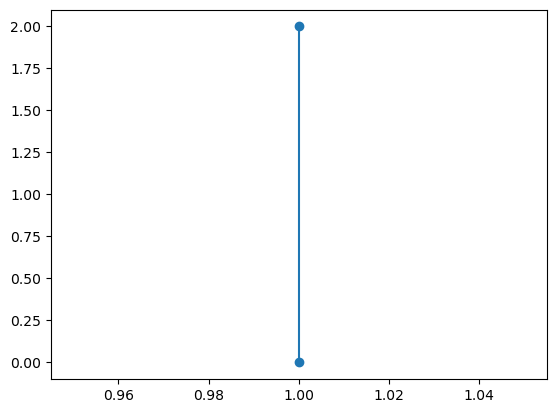

In [39]:
plt.plot([1,1],[0,2],'o-')

Text(0, 0.5, 'Y axis')

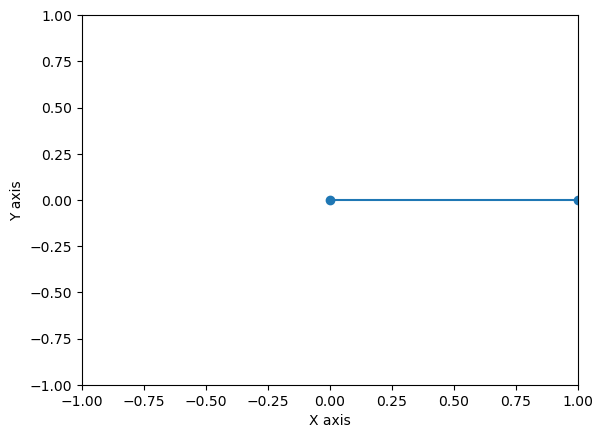

In [41]:
plt.plot([0, vec1[0,0]], [0, vec1[1,0]], 'o-')
plt.axis([-1, 1, -1, 1])
plt.xlabel('X axis')
plt.ylabel('Y axis')

## Switch to plotting in an external window

In [42]:
%matplotlib qt

In [44]:
plt.plot([0, vec1[0,0]], [0, vec1[1,0]], 'o-')
plt.axis([-1, 1, -1, 1])

(-1.0, 1.0, -1.0, 1.0)

In [45]:
plt.xlabel('X axis')
plt.ylabel('Y axis')

Text(35.94444444444443, 0.5, 'Y axis')

## Switch to plotting in the document (this is necessary for turning in your assignments)

In [46]:
%matplotlib inline
plt.ion() # turns interactive plotting on so plots display right after code execution

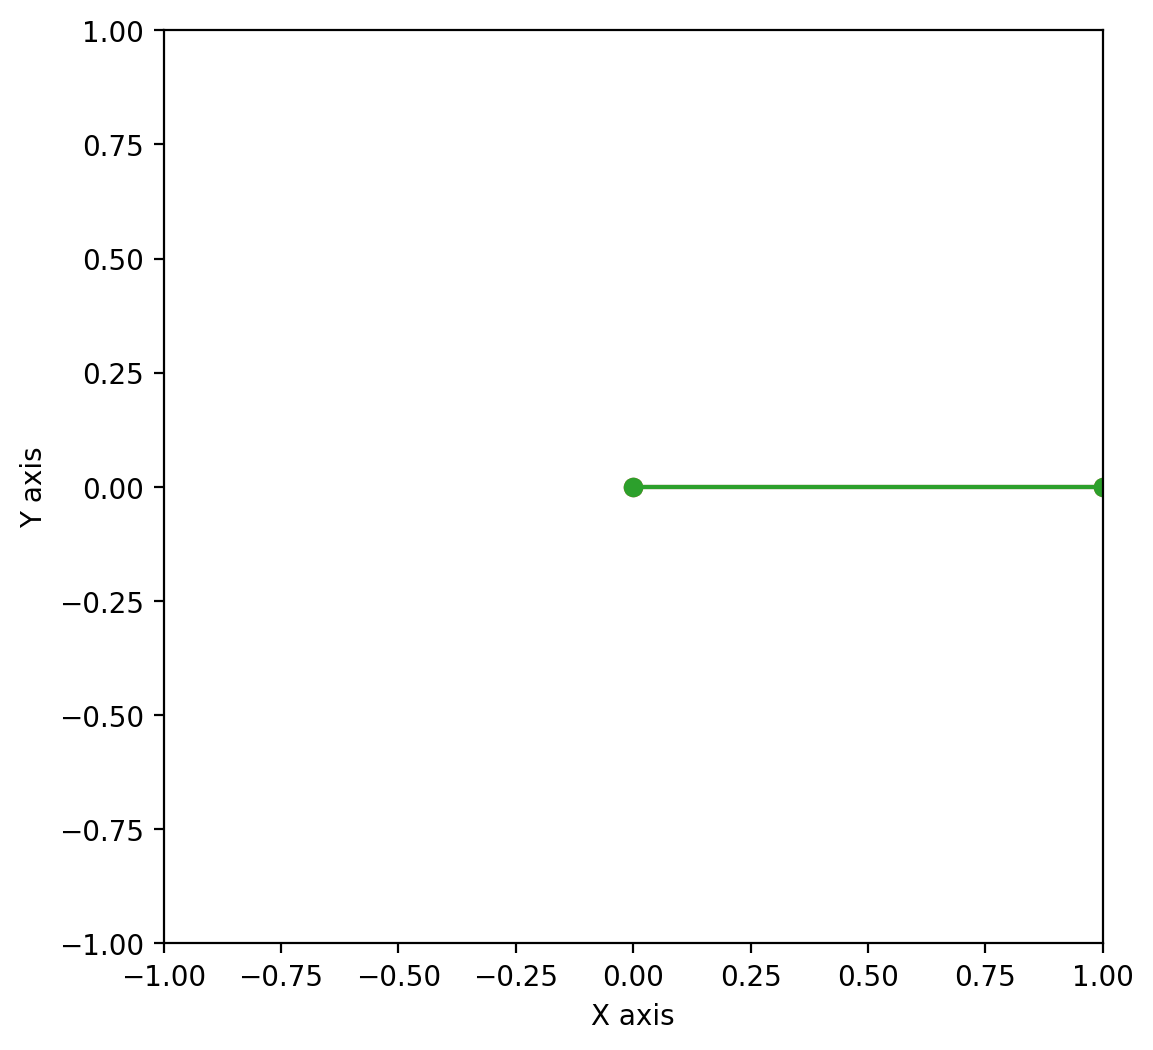

In [47]:
plt.plot([0, vec1[0,0]], [0, vec1[1,0]], 'o-')
plt.axis([-1, 1, -1, 1])
plt.show()

## Switch back to qt so we can make some animations

In [48]:
%matplotlib qt

In [49]:
newvec = rotate(np.pi/8) @ vec1

plt.plot([0, newvec[0,0]], [0, newvec[1,0]], 'o-')
plt.axis([-1, 1, -1, 1])

(-1.0, 1.0, -1.0, 1.0)

In [50]:
angles = np.linspace(0, 4*np.pi, 100)
for ang in angles:
    
    newvec = rotate(ang) @ vec1

    plt.clf()    
    plt.plot([0, newvec[0,0]], [0, newvec[1,0]], 'o-')
    plt.axis([-1, 1, -1, 1])
#     plt.draw()
    plt.pause(0.01)
    
    
    

## How to plot many points (when represented as column vectors)

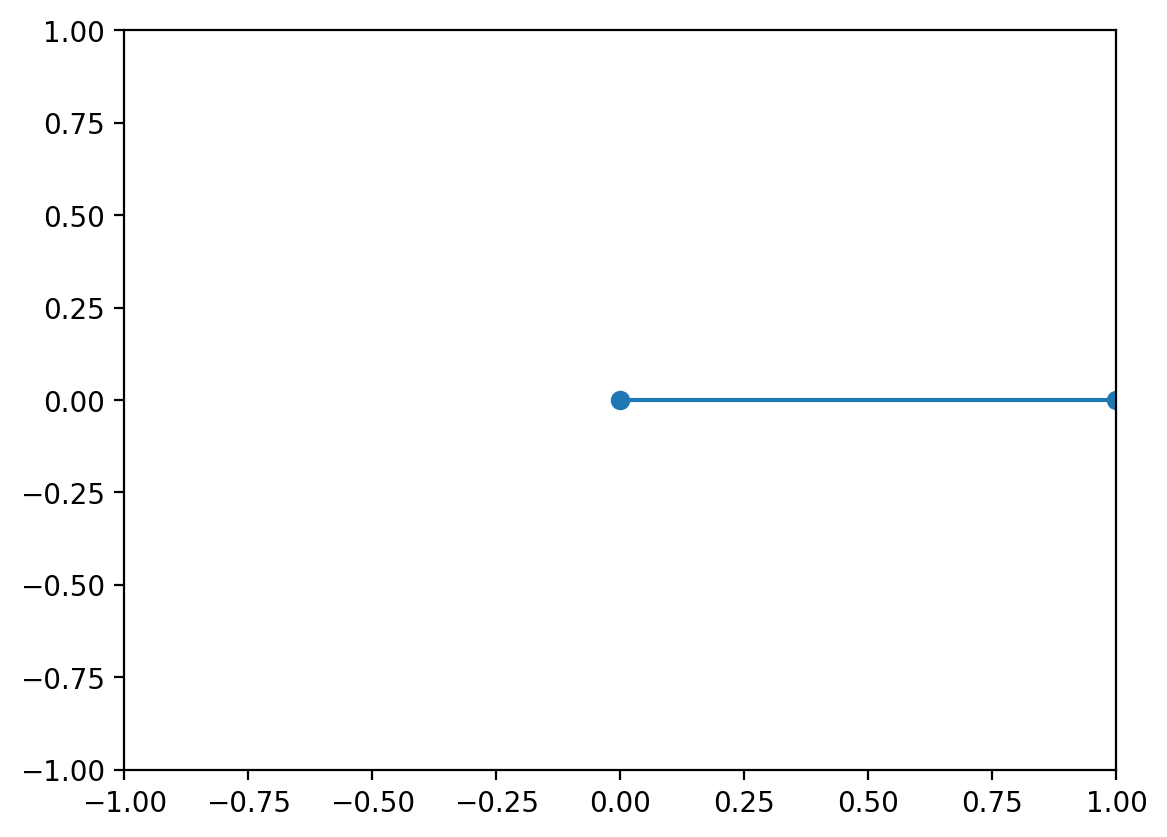

In [51]:
%matplotlib inline
plt.ion()
plt.show()

In [52]:
points = np.array([[1, 2, 3, 4],
                   [0, 5, 8, -9]])
points                

array([[ 1,  2,  3,  4],
       [ 0,  5,  8, -9]])

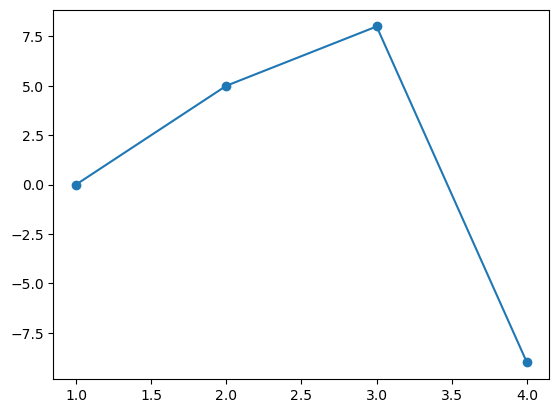

In [54]:
plt.plot(points[0,:], points[1,:], '-o')

In [55]:
rotate(np.pi/8) @ points

array([[ 0.92387953, -0.0656581 , -0.28982886,  7.13966902],
       [ 0.38268343,  5.38476453,  8.53908656, -6.78418206]])

In [56]:
pts_dict = {'x': points[0,:], 'y': points[1,:]}

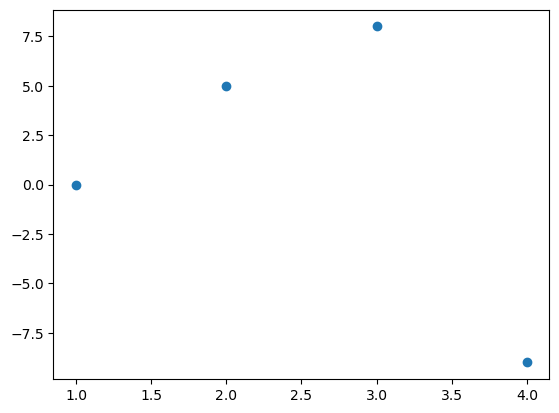

In [57]:
plt.plot(pts_dict['x'], pts_dict['y'],'o')

## Plot a coordinate system and then move it around

In [41]:
origin = np.eye(3)
origin

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [42]:
new_coord_sys = np.array([[0.7115,    0.4325,   -0.5538],
                          [0.6388,   -0.7264,    0.2535],
                          [-0.2927,   -0.5341,   -0.7931]])

In [49]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d', adjustable='box')

def plot_frame(R, ax):
    ax.plot([0, R[0,0]], [0, R[1,0]], [0, R[2,0]], 'r')
    ax.plot([0, R[0,1]], [0, R[1,1]], [0, R[2,1]], 'g')
    ax.plot([0, R[0,2]], [0, R[1,2]], [0, R[2,2]], 'b')

plot_frame(origin, ax)
ax.axis('equal')

(-0.16666666666666674,
 1.1666666666666667,
 -0.16666666666666674,
 1.1666666666666667)

In [50]:
# %matplotlib qt

# plt.figure(1)
plot_frame(new_coord_sys, ax)
ax.axis('equal')

(-0.9722999999999999, 1.4185, -1.0586000000000002, 1.3321999999999998)

In [51]:
np.linalg.det(new_coord_sys)

0.9999556465280001

In [52]:
np.dot(new_coord_sys[:,0], new_coord_sys[:,1])

3.0499999999986474e-05

In [81]:
new_coord_sys[:,0].T @ new_coord_sys[:,1]

3.0499999999986474e-05

Again use @ for vector and matrix multiplication

In [82]:
new_coord_sys[:,0].T * new_coord_sys[:,1]

array([ 0.30772375, -0.46402432,  0.15633107])

## Introduction to Sympy tools

In [58]:
import sympy
from sympy import simplify, Function
from sympy import symbols, pprint
from sympy import sin, cos, asin, acos, pi
from sympy import Matrix, diff


### Generate sympy variables

In [59]:
b = symbols('b', real = True)

In [60]:
b

b

In [63]:
q = symbols('Q', real = True)
q

Q

In [64]:
b*q

Q*b

In [65]:
# We wrap in parentheses here so we can write it on multiple lines. Similar
# with the triple quotes on the string. Usually we don't need to use these things.
(t, 
 alpha, 
 gamma, 
 beta) = symbols("""t, 
                    alpha,
                    gamma,
                    beta""" , real = True)

theta = Function('theta', real=True)(t)
alpha = Function('alpha', real=True)(t)

## Define a rotation matrix about Z

In [69]:
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

In [70]:
R_z(alpha)

Matrix([
[cos(alpha(t)), -sin(alpha(t)), 0],
[sin(alpha(t)),  cos(alpha(t)), 0],
[            0,              0, 1]])

In [71]:
diff(R_z(alpha), t)

Matrix([
[-sin(alpha(t))*Derivative(alpha(t), t), -cos(alpha(t))*Derivative(alpha(t), t), 0],
[ cos(alpha(t))*Derivative(alpha(t), t), -sin(alpha(t))*Derivative(alpha(t), t), 0],
[                                     0,                                      0, 0]])

Verify that $$\dot{R}R^T = [\omega]_\times$$

In [72]:
diff(R_z(alpha), t)

simplify(diff(R_z(alpha), t) @ R_z(alpha).T)

Matrix([
[                      0, -Derivative(alpha(t), t), 0],
[Derivative(alpha(t), t),                        0, 0],
[                      0,                        0, 0]])

In [61]:
simplify(diff(R_z(alpha), t) @ R_z(alpha).T)

Matrix([
[                      0, -Derivative(alpha(t), t), 0],
[Derivative(alpha(t), t),                        0, 0],
[                      0,                        0, 0]])